In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import os
from patchify import patchify  #Only to handle large images
import random
from scipy import ndimage
import glob
import cv2
from tqdm import tqdm
import torch
import scipy

In [2]:
#Used to quickly display an image
def imshow(img, title, cmap = 'gray', axis = 'off', figsize = (10, 10)):
    plt.figure(figsize= figsize)
    plt.imshow(img, cmap = cmap)
    plt.title(title)
    plt.axis(axis)
    plt.show()  

In [3]:
#Storing all file paths of images in a list of strings
import os
directory = r"C:\Users\adamain\Downloads\ProcessedSpiderWebs"
image_paths = []
for filename in os.listdir(directory):
    if filename.lower().endswith(".png"):
        image_paths.append(os.path.join(directory, filename))
print(image_paths)

['C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - C_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - C_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 4_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26

In [4]:
all_images = []
for path in image_paths:
    all_images.append(cv2.imread(path))
    cv2.cvtColor(all_images[len(all_images)-1], cv2.COLOR_BGR2RGB)

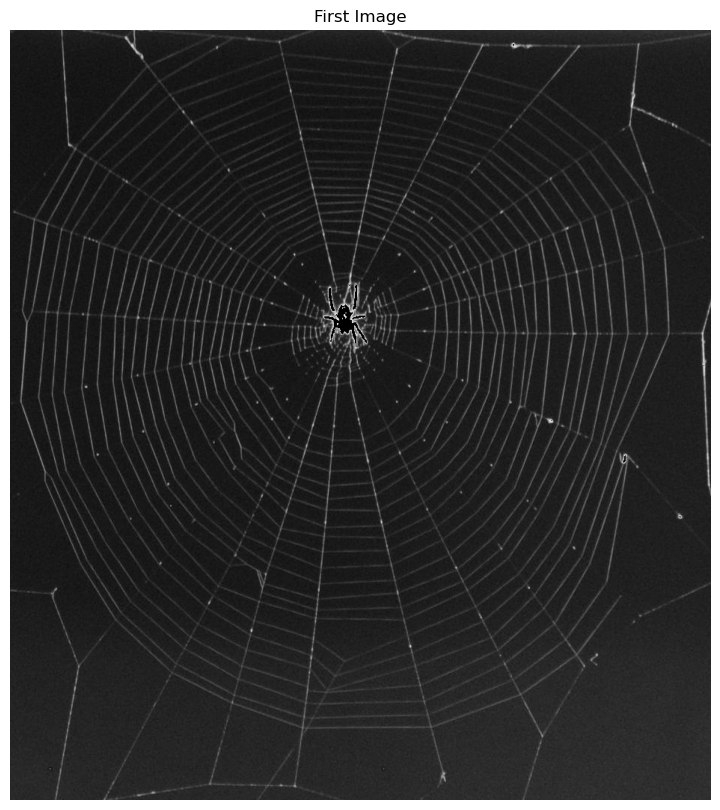

In [5]:
imshow(all_images[0], title = "First Image")

In [35]:
import cv2
import numpy as np

def apply_multi_gabor(gray, orientations=8, ksize=21):
    """
    Apply multiple Gabor filters to enhance line structures in various directions.
    """
    filtered_imgs = []
    for theta in np.linspace(0, np.pi, orientations, endpoint=False):
        kernel = cv2.getGaborKernel((ksize, ksize), sigma=4.0, theta=theta,
                                    lambd=10.0, gamma=0.5, psi=0, ktype=cv2.CV_32F)
        filtered = cv2.filter2D(gray, cv2.CV_8UC1, kernel)
        filtered_imgs.append(filtered)
    return np.max(filtered_imgs, axis=0)

def enhance_spider_web_smart2(gray_image):
    """
    Smarter enhancement: Tophat + multi-orientation Gabor filters + CLAHE.
    Designed to target spider web geometries more robustly.
    """
    gray = gray_image.copy()

    # Step 1: Morphological tophat
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,5))
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)

    # Step 2: Gabor filters for radial/circular lines
    gabor_enhanced = apply_multi_gabor(tophat, orientations=12, ksize=25)
    # Step 3: CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    final = clahe.apply(gabor_enhanced)

    return final


In [34]:
def preprocess_web(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    results = enhance_spider_web_smart2(gray)
    _, edited = cv2.threshold(results, 220, 255, cv2.THRESH_BINARY) 
    imshow(edited, title = "Results")
    return edited

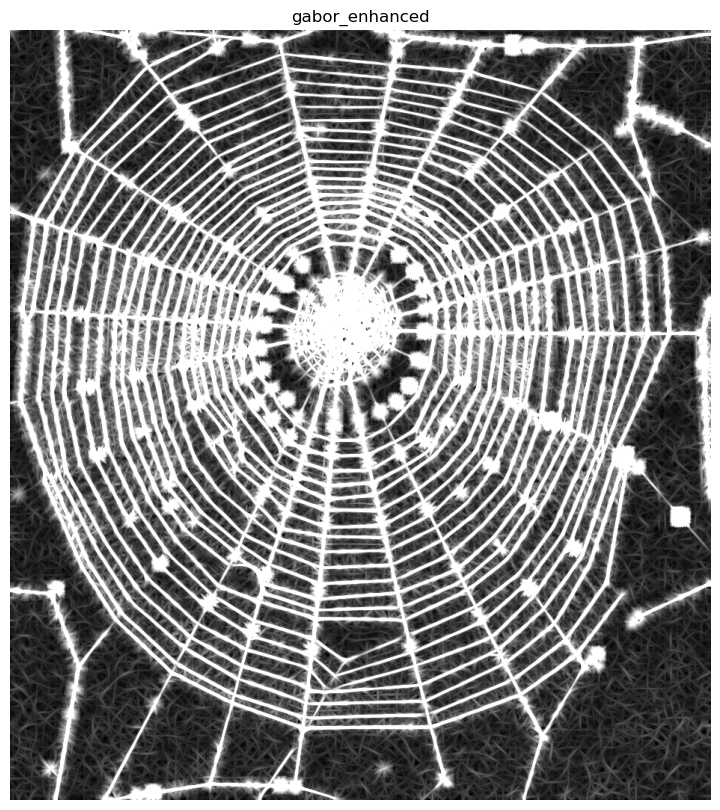

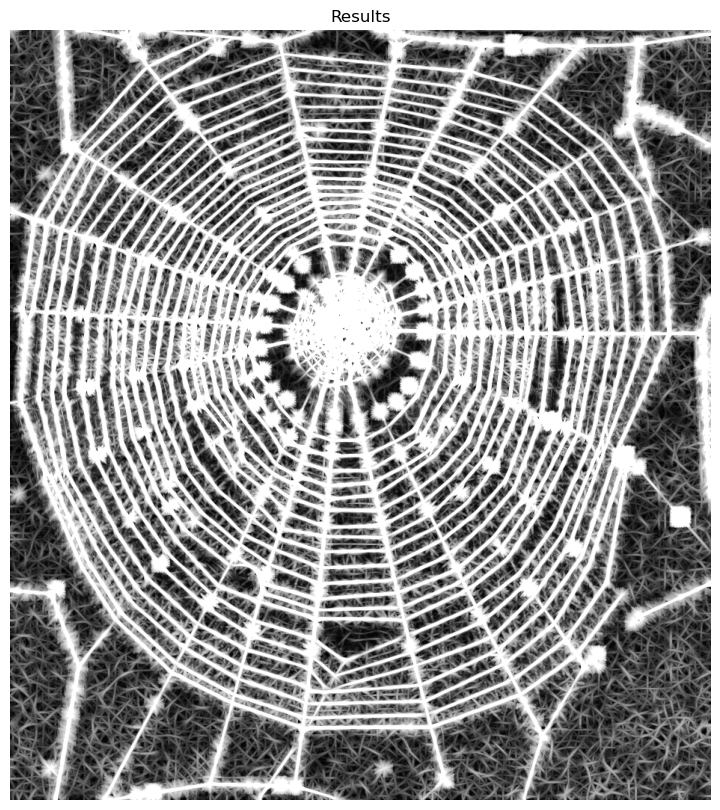

In [7]:
gray = cv2.cvtColor(all_images[0], cv2.COLOR_BGR2GRAY)
results = enhance_spider_web_smart2(gray)
imshow(results, "Results")

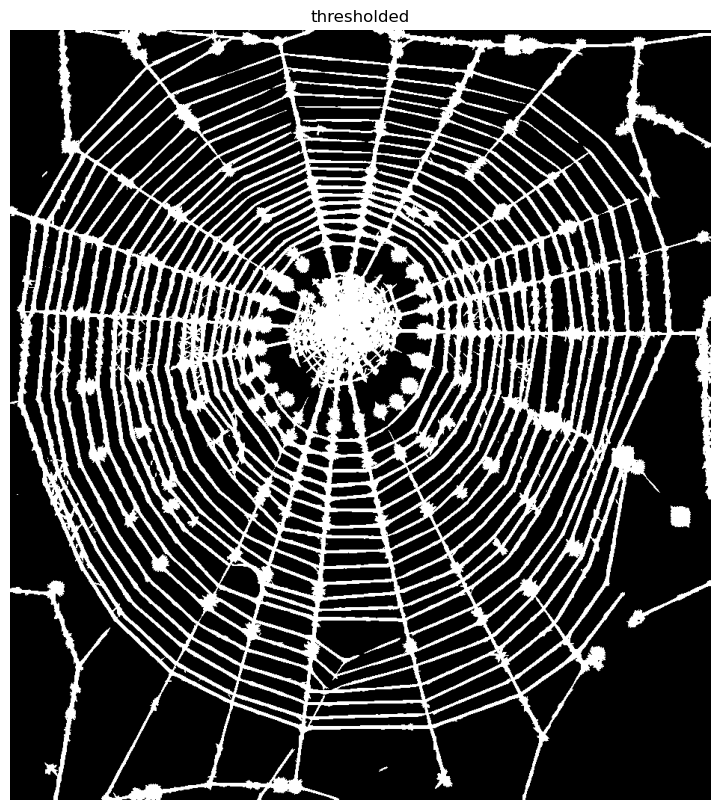

In [8]:
_, edited = cv2.threshold(results, 220, 255, cv2.THRESH_BINARY) 
imshow(edited, title = "thresholded")
#Try using the bright circles to your advantage. We know that they are they because web passes through them, so reconstruct radials passing through bright circles.Then calculate an average radius for the radials and get angle between them (might be easier)

In [9]:
import torch
from segment_anything import sam_model_registry, SamPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Point to SAM1 checkpoint, e.g. sam_vit_h_4b8939.pth
checkpoint_path = r"C:\Users\adamain\Downloads\sam_vit_h_4b8939.pth"

# Use correct key based on model variant: vit_h, vit_l, or vit_b
model_type = "vit_h"
model = sam_model_registry[model_type](checkpoint=checkpoint_path)
model.to(device)
model.eval()

predictor = SamPredictor(model)



Circle: center=(446, 398), capped radius=80, score=0.960


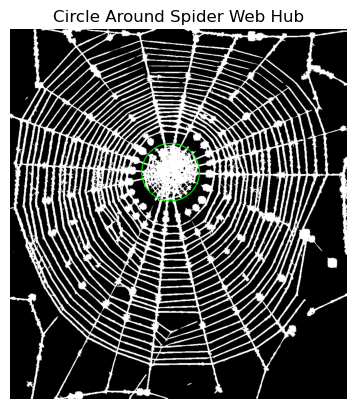

In [ ]:
import numpy as np
import cv2
from sklearn.linear_model import RANSACRegressor
import matplotlib.pyplot as plt

# --- Inputs ---
positive_points = [(450, 350), (450, 400)]  # Points inside the hub
negative_points = [(100, 100), (500, 100)]  # Points outside the hub
image = edited

input_points = np.array(positive_points + negative_points)
input_labels = np.array([1]*len(positive_points) + [0]*len(negative_points))

# Ensure image is 3-channel RGB for SAM
if len(image.shape) == 2:
    image = np.stack([image]*3, axis=-1)
elif image.shape[2] == 1:
    image = np.repeat(image, 3, axis=2)

predictor.set_image(image)

masks, scores, _ = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

def fit_circle(mask):
    ys, xs = np.where(mask)
    if len(xs) < 5:
        return None
    x = xs[:, np.newaxis]
    y = ys[:, np.newaxis]
    A = np.hstack([2 * x, 2 * y, np.ones_like(x)])
    b = x**2 + y**2
    model = RANSACRegressor()
    model.fit(A, b)
    c = model.estimator_.coef_
    d = model.estimator_.intercept_
    cx = int(c[0][0])
    cy = int(c[0][1])
    r = int(np.sqrt(d + c[0][0]**2 + c[0][1]**2)[0])
    return (cx, cy, r)

best_idx = np.argmax(scores)
best_mask = masks[best_idx]
best_score = scores[best_idx]
fallback_circle = fit_circle(best_mask)
cx, cy, r = fallback_circle
r = 80
print(f"Circle: center=({cx}, {cy}), capped radius={r}, score={best_score:.3f}")

output_image = image.copy()
if cx is not None and cy is not None and r is not None:
    cv2.circle(output_image, (cx, cy), r, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title("Circle Around Spider Web Hub")
plt.axis("off")
plt.show()


In [28]:
import numpy as np
import cv2
from scipy.ndimage import center_of_mass
from sklearn.linear_model import RANSACRegressor
import matplotlib.pyplot as plt

def sample_local_points(mask, center, radius=30, n_points=8):
    ys, xs = np.where(mask)
    coords = np.stack([xs, ys], axis=1)
    dists = np.linalg.norm(coords - np.array(center), axis=1)
    local_coords = coords[dists < radius]
    if len(local_coords) == 0:
        return np.empty((0, 2), dtype=int)
    idxs = np.linspace(0, len(local_coords)-1, min(n_points, len(local_coords))).astype(int)
    return local_coords[idxs]

def fit_circle_from_mask(mask):
    ys, xs = np.where(mask)
    if len(xs) < 5:
        return None
    x = xs[:, np.newaxis]
    y = ys[:, np.newaxis]
    A = np.hstack([2 * x, 2 * y, np.ones_like(x)])
    b = x**2 + y**2
    model = RANSACRegressor()
    model.fit(A, b)
    c = model.estimator_.coef_
    d = model.estimator_.intercept_
    cx = int(c[0][0])
    cy = int(c[0][1])
    r = int(np.sqrt(d + c[0][0]**2 + c[0][1]**2)[0])
    return (cx, cy, r)

def find_hub_center_from_reference(reference_mask, new_image, predictor, 
                                   center_radius=30, n_points=8, 
                                   min_radius=20, max_radius=150, 
                                   draw=True):
    # Step 1: Get center of reference mask
    cy, cx = center_of_mass(reference_mask)
    pos_points = sample_local_points(reference_mask, (cx, cy), radius=center_radius, n_points=n_points)

    if len(pos_points) == 0:
        print("No valid positive points extracted.")
        return new_image.copy(), None

    input_points = pos_points
    input_labels = np.ones(len(pos_points))

    # Step 2: Ensure image is RGB
    if len(new_image.shape) == 2:
        new_image = np.stack([new_image]*3, axis=-1)
    elif new_image.shape[2] == 1:
        new_image = np.repeat(new_image, 3, axis=2)

    predictor.set_image(new_image)

    # Step 3: Run SAM
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    # Step 4: Evaluate masks
    valid_results = []
    for mask, score in zip(masks, scores):
        result = fit_circle_from_mask(mask)
        if result is None:
            continue
        cx, cy, r = result
        if min_radius <= r <= max_radius:
            valid_results.append((result, score, mask))

    if valid_results:
        (cx, cy, r), best_score, best_mask = sorted(valid_results, key=lambda x: x[1], reverse=True)[0]
    else:
        # fallback to best SAM mask and clamp radius
        idx = np.argmax(scores)
        best_mask = masks[idx]
        result = fit_circle_from_mask(best_mask)
        if result is None:
            return new_image.copy(), None
        cx, cy, r = result
        r = max(min(r, max_radius), min_radius)

    # Step 5: Draw result
    output_image = new_image.copy()
    if draw:
        cv2.circle(output_image, (cx, cy), r, (0, 0, 255), 2)
        plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
        plt.title("Hub Center and Circle")
        plt.axis("off")
        plt.show()

    return output_image, (cx, cy)


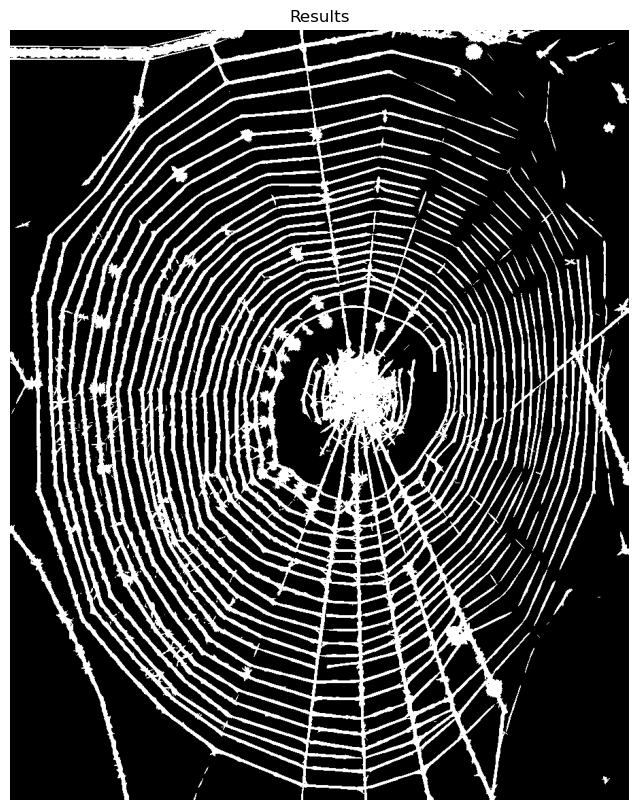

In [36]:
#Preprocess test image
test_im = preprocess_web(all_images[1])

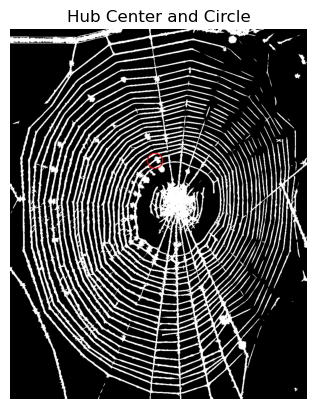

In [ ]:
#Fix this to generalize to finding the centers well and then send them off for further analysis. Maybe start to separate this process out into multiple notebooks
test, test_center = find_hub_center_from_reference(best_mask, test_im, predictor)

In [23]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

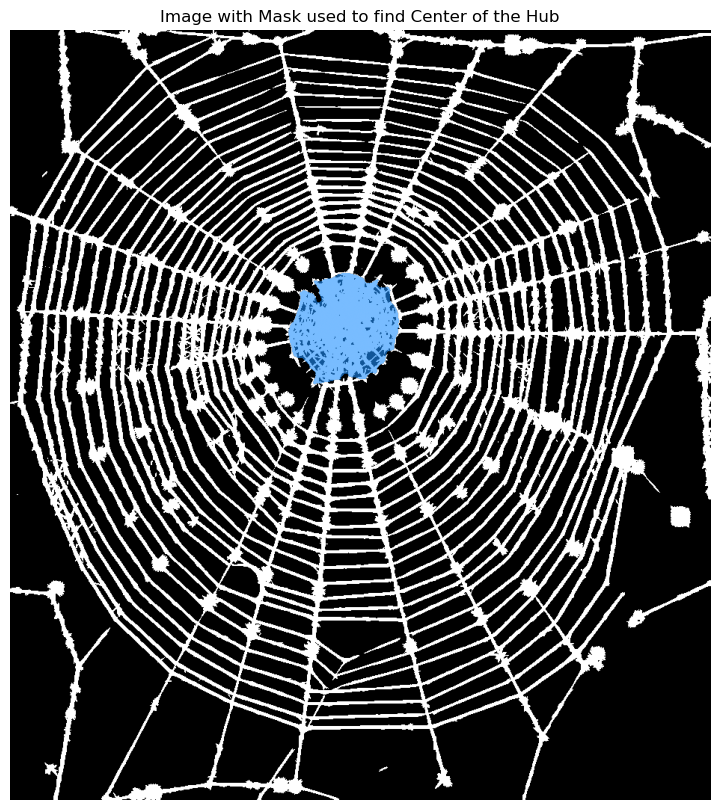

In [27]:
plt.figure(figsize=(10,10))
plt.imshow(edited, cmap = 'gray')
show_mask(best_mask, plt.gca())
plt.title("Image with Mask used to find Center of the Hub")
plt.axis('off')
plt.show()  

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List
import math
import scipy.signal


class SpiderWebAnalyzer:
    def __init__(self, image_path: str = None, image: np.ndarray = None):
        if image is not None:
            self.image = image
        elif image_path is not None:
            self.image = cv2.imread(image_path)
            if self.image is None:
                raise ValueError(f"Could not load image from {image_path}")
        else:
            raise ValueError("Either image_path or image must be provided")

        self.image_rgb = cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB)
        self.image_gray = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
        self.center = None
        self.radius = None

    def set_center_and_radius(self, center: Tuple[int, int], radius: int):
        self.center = center
        self.radius = radius

    def detect_center_interactive(self):
        def mouse_callback(event, x, y, flags, param):
            if event == cv2.EVENT_LBUTTONDOWN:
                self.center = (x, y)
                print(f"Center set to: ({x}, {y})")

        cv2.namedWindow('Click Center Point', cv2.WINDOW_NORMAL)
        cv2.setMouseCallback('Click Center Point', mouse_callback)

        temp_image = self.image.copy()
        cv2.imshow('Click Center Point', temp_image)

        print("Click on the center of the spider web hub, then press any key...")
        cv2.waitKey(0)
        cv2.destroyAllWindows()

        if self.center is None:
            raise ValueError("No center point was selected")

    def create_radial_lines(self, line_length: int = None) -> List[Tuple[np.ndarray, np.ndarray]]:
        if self.center is None:
            raise ValueError("Center point must be set first")

        if line_length is None:
            line_length = self.radius if self.radius else min(self.image.shape[:2]) // 2

        lines = []
        center_x, center_y = self.center

        for angle_deg in range(360):
            angle_rad = math.radians(angle_deg)
            end_x = int(center_x + line_length * math.cos(angle_rad))
            end_y = int(center_y + line_length * math.sin(angle_rad))
            x_coords, y_coords = self._bresenham_line(center_x, center_y, end_x, end_y)
            lines.append((x_coords, y_coords))

        return lines

    def _bresenham_line(self, x0: int, y0: int, x1: int, y1: int) -> Tuple[np.ndarray, np.ndarray]:
        dx = abs(x1 - x0)
        dy = abs(y1 - y0)
        sx = 1 if x0 < x1 else -1
        sy = 1 if y0 < y1 else -1
        err = dx - dy

        x_coords, y_coords = [], []
        x, y = x0, y0

        while True:
            x_coords.append(x)
            y_coords.append(y)
            if x == x1 and y == y1:
                break
            e2 = 2 * err
            if e2 > -dy:
                err -= dy
                x += sx
            if e2 < dx:
                err += dx
                y += sy

        return np.array(x_coords), np.array(y_coords)

    def score_lines_by_white_pixels(self, lines: List[Tuple[np.ndarray, np.ndarray]], white_threshold: int = 240) -> List[int]:
        scores = []
        height, width = self.image_gray.shape

        for x_coords, y_coords in lines:
            valid_mask = (x_coords >= 0) & (x_coords < width) & (y_coords >= 0) & (y_coords < height)
            valid_x = x_coords[valid_mask]
            valid_y = y_coords[valid_mask]
            if len(valid_x) > 0:
                pixel_values = self.image_gray[valid_y, valid_x]
                white_count = np.sum(pixel_values >= white_threshold)
                scores.append(white_count)
            else:
                scores.append(0)

        return scores

    def find_peak_lines(self, scores: List[int], min_height: int = 50) -> List[int]:
        peaks, _ = scipy.signal.find_peaks(scores, height=min_height)
        return peaks.tolist()

    def filter_peaks_by_angle(self, peak_indices: List[int], scores: List[int], angle_thresh: int = 5) -> List[int]:
        if not peak_indices:
            return []

        sorted_peaks = sorted(peak_indices)
        filtered_peaks = []
        current_cluster = [sorted_peaks[0]]

        for i in range(1, len(sorted_peaks)):
            if sorted_peaks[i] - sorted_peaks[i - 1] <= angle_thresh:
                current_cluster.append(sorted_peaks[i])
            else:
                best_peak = max(current_cluster, key=lambda idx: scores[idx])
                filtered_peaks.append(best_peak)
                current_cluster = [sorted_peaks[i]]

        if current_cluster:
            best_peak = max(current_cluster, key=lambda idx: scores[idx])
            filtered_peaks.append(best_peak)

        return filtered_peaks

    def visualize_analysis(self, lines: List[Tuple[np.ndarray, np.ndarray]], scores: List[int],
                           show_all_lines: bool = False, show_top_n: int = 10,
                           highlight_peaks: bool = False, min_height: int = 50,
                           angle_filter_deg: int = 5):
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

        ax1.imshow(self.image_rgb)
        ax1.set_title('Original Image')
        ax1.axis('off')

        ax2.imshow(self.image_rgb)
        if self.center:
            ax2.plot(self.center[0], self.center[1], 'ro', markersize=8, label='Center')
        if self.radius and self.center:
            circle = plt.Circle(self.center, self.radius, fill=False, color='green', linewidth=2)
            ax2.add_patch(circle)
        ax2.set_title('Center and Analysis Circle')
        ax2.legend()
        ax2.axis('off')

        ax3.imshow(self.image_rgb)
        if self.center:
            ax3.plot(self.center[0], self.center[1], 'ro', markersize=8)

        if lines and scores:
            if highlight_peaks:
                peak_indices = self.find_peak_lines(scores, min_height=min_height)
                peak_indices = self.filter_peaks_by_angle(peak_indices, scores, angle_thresh=angle_filter_deg)
                for i in peak_indices:
                    x_coords, y_coords = lines[i]
                    ax3.plot(x_coords, y_coords, 'b-', linewidth=2, alpha=0.8)
            else:
                top_indices = np.argsort(scores)[-show_top_n:]
                for i in top_indices:
                    x_coords, y_coords = lines[i]
                    ax3.plot(x_coords, y_coords, 'r-', linewidth=1, alpha=0.7)

        if show_all_lines and lines:
            for x_coords, y_coords in lines:
                ax3.plot(x_coords, y_coords, 'gray', linewidth=0.5, alpha=0.3)

        ax3.set_title('Radial Lines Highlighted')
        ax3.axis('off')

        ax4.bar(range(len(scores)), scores, alpha=0.7)
        ax4.set_title('White Pixel Scores by Angle')
        ax4.set_xlabel('Angle (degrees)')
        ax4.set_ylabel('White Pixel Count')

        if highlight_peaks:
            peak_indices = self.find_peak_lines(scores, min_height=min_height)
            peak_indices = self.filter_peaks_by_angle(peak_indices, scores, angle_thresh=angle_filter_deg)
            for i in peak_indices:
                ax4.bar(i, scores[i], color='blue', alpha=0.9)
            ax4.axhline(min_height, color='red', linestyle='--', label='Min Brightness Threshold')
            ax4.legend()
        else:
            top_indices = np.argsort(scores)[-show_top_n:]
            for i in top_indices:
                ax4.bar(i, scores[i], color='red', alpha=0.8)

        plt.tight_layout()
        plt.show()

    def get_analysis_stats(self, scores: List[int]) -> dict:
        if not scores:
            return {}

        scores_array = np.array(scores)

        stats = {
            'total_lines': len(scores),
            'mean_score': np.mean(scores_array),
            'median_score': np.median(scores_array),
            'std_score': np.std(scores_array),
            'min_score': np.min(scores_array),
            'max_score': np.max(scores_array),
            'top_10_angles': np.argsort(scores_array)[-10:].tolist(),
            'top_10_scores': sorted(scores_array)[-10:]
        }

        return stats
    def draw_lines_on_image(self, lines: List[Tuple[np.ndarray, np.ndarray]], color=(0, 0, 255), thickness=1) -> np.ndarray:
        """
        Draws the given lines on a copy of the original image.

        Args:
            lines: List of (x_coords, y_coords) tuples
            color: BGR color of the lines
            thickness: Line thickness

        Returns:
            Image with lines drawn (as a NumPy array)
        """
        image_copy = self.image.copy()
        for x_coords, y_coords in lines:
            for i in range(1, len(x_coords)):
                pt1 = (int(x_coords[i - 1]), int(y_coords[i - 1]))
                pt2 = (int(x_coords[i]), int(y_coords[i]))
                cv2.line(image_copy, pt1, pt2, color, thickness)
        return image_copy


#Usage Function (Runs it once)
def analyze_spider_web(image_path: str = None, image: np.ndarray = None,
                       center: Tuple[int, int] = None, radius: int = None,
                       interactive: bool = False, peak_min_height: int = 50,
                       angle_filter_deg: int = 5):
    analyzer = SpiderWebAnalyzer(image_path=image_path, image=image)

    if interactive:
        analyzer.detect_center_interactive()
    elif center:
        analyzer.set_center_and_radius(center, radius)
    else:
        h, w = analyzer.image.shape[:2]
        analyzer.set_center_and_radius((w // 2, h // 2), min(w, h) // 4)

    print("Creating 360 radial lines...")
    all_lines = analyzer.create_radial_lines()

    print("Scoring lines by white pixel count...")
    scores = analyzer.score_lines_by_white_pixels(all_lines)

    print("Finding peak lines...")
    raw_peak_indices = analyzer.find_peak_lines(scores, min_height=peak_min_height)
    peak_indices = analyzer.filter_peaks_by_angle(raw_peak_indices, scores, angle_thresh=angle_filter_deg)
    peak_lines = [all_lines[i] for i in peak_indices]

    stats = analyzer.get_analysis_stats(scores)

    print("\n--- Analysis Results ---")
    print(f"Total lines analyzed: {stats['total_lines']}")
    print(f"Mean white pixel score: {stats['mean_score']:.2f}")
    print(f"Standard deviation: {stats['std_score']:.2f}")
    print(f"Min score: {stats['min_score']}, Max score: {stats['max_score']}")
    print(f"Top 10 scoring angles: {stats['top_10_angles']}")
    print(f"Top 10 scores: {stats['top_10_scores']}")

    analyzer.visualize_analysis(all_lines, scores,
                                show_all_lines=False,
                                highlight_peaks=True,
                                min_height=peak_min_height,
                                angle_filter_deg=angle_filter_deg)

    output_image_with_lines = analyzer.draw_lines_on_image(peak_lines, color=(0, 0, 255), thickness=1)

    return analyzer, peak_lines, scores, stats, output_image_with_lines
#More robust usage function running many trials
import matplotlib.pyplot as plt

import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

def robust_spider_web_analysis(image: np.ndarray,
                               center: Tuple[int, int],
                               radii: List[int],
                               white_threshold: int = 240,
                               peak_min_height: int = 50,
                               angle_filter_deg: int = 5,
                               vote_threshold: int = 3,
                               show_debug: bool = True) -> Tuple[List[int], List[Tuple[np.ndarray, np.ndarray]], np.ndarray]:
    """
    Run spider web analysis over multiple radii and retain only stable radial lines.

    Args:
        image: Input BGR image as a NumPy array
        center: (x, y) center of the web
        radii: List of radii to try
        white_threshold: Threshold for white pixel detection
        peak_min_height: Minimum white pixel score to consider a peak
        angle_filter_deg: Min angular separation between peaks (for clustering)
        vote_threshold: Minimum number of times a peak must appear to be accepted
        show_debug: If True, show debug plots

    Returns:
        stable_angles: List of selected peak angles
        stable_lines: List of line coordinate tuples (x_coords, y_coords)
        output_image: Image with stable lines drawn
    """

    # Bin of angles (0-359) each containing candidate peaks
    angle_bins = [[] for _ in range(360)]
    angle_to_lines = {}

    for radius in radii:
        analyzer = SpiderWebAnalyzer(image=image)
        analyzer.set_center_and_radius(center, radius)
        lines = analyzer.create_radial_lines()
        scores = analyzer.score_lines_by_white_pixels(lines, white_threshold=white_threshold)
        raw_peaks = analyzer.find_peak_lines(scores, min_height=peak_min_height)
        filtered_peaks = analyzer.filter_peaks_by_angle(raw_peaks, scores, angle_thresh=angle_filter_deg)

        for angle in filtered_peaks:
            for delta in range(-5, 6):  # ±5° tolerance
                bin_angle = (angle + delta) % 360
                angle_bins[bin_angle].append((angle, lines[angle]))
                # Store line only if not already stored for that bin
                if bin_angle not in angle_to_lines:
                    angle_to_lines[bin_angle] = lines[angle]

    # Count how often each angle bin got votes
    vote_counts = [len(bin) for bin in angle_bins]

    # Raw stable angle candidates
    raw_stable_angles = [i for i, count in enumerate(vote_counts) if count >= vote_threshold]

    # Final stable angle filtering using radius preference
    used_angles = set()
    final_stable_angles = []
    final_stable_lines = []

    for angle in raw_stable_angles:
        if angle in used_angles:
            continue

        # Group all angles within ±5°
        cluster = [(a % 360) for a in range(angle - 5, angle + 6)]
        cluster = [a for a in cluster if a in raw_stable_angles]

        # Choose angle with highest white density
        def white_density_score(a):
            x_coords, y_coords = angle_to_lines[a]
            radius = np.linalg.norm([x_coords[-1] - center[0], y_coords[-1] - center[1]])
            white_score_estimate = len([b for b in angle_bins[a] if b[0] == a])
            return white_score_estimate / radius if radius > 0 else 0

        best_angle = max(cluster, key=white_density_score)

        final_stable_angles.append(best_angle)
        final_stable_lines.append(angle_to_lines[best_angle])
        used_angles.update(cluster)



    # Draw the final result
    final_analyzer = SpiderWebAnalyzer(image=image)
    output_image = final_analyzer.draw_lines_on_image(final_stable_lines, color=(0, 0, 255), thickness=2)

    # Debug visualization
    if show_debug:
        fig, axs = plt.subplots(1, 2, figsize=(16, 6))

        axs[0].imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
        axs[0].set_title("Stable Radial Lines (Drawn on Image)")
        axs[0].axis("off")

        axs[1].bar(range(360), vote_counts, color='gray')
        axs[1].set_title("Angle Vote Histogram (±5° tolerance)")
        axs[1].set_xlabel("Angle (degrees)")
        axs[1].set_ylabel("Vote Count")

        for angle in final_stable_angles:
            axs[1].bar(angle, vote_counts[angle], color='green')

        plt.tight_layout()
        plt.show()

    return final_stable_angles, final_stable_lines, output_image




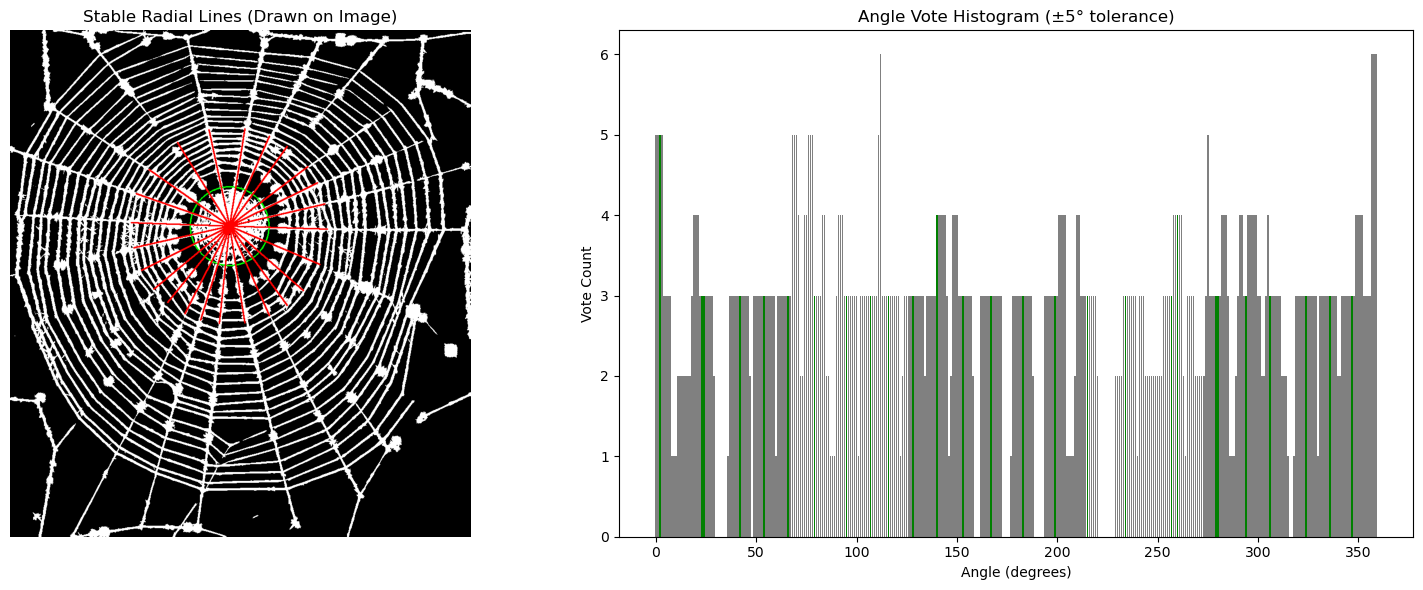

In [ ]:
radii = [200, 300, 400]
angles, lines, line_img = robust_spider_web_analysis(
    image = output_image,
    radii = radii,
    center=(cx, cy),
    peak_min_height=90,
    vote_threshold = len(radii)
)

In [21]:
import os
output_dir = r"C:\Users\adamain\Documents\Annotated Spiders"
base_name = os.path.basename(image_paths[0])
name_without_ext = os.path.splitext(base_name)[0]
annotated_path = os.path.join(output_dir, f"{name_without_ext}_annotated.png")
cv2.imwrite(annotated_path, line_img)

True